# A/B Landing Page Experiment

The objective of this project is to evaluate an **A/B experiment** conducted on a landing page with versions **A and B** to support a **data-driven business decision**.

---

The `landing_experiment.csv` file contains information on users exposed to two versions of the landing page within the A/B experiment. It includes region, device, traffic source, user type, conversion, and spending.

The analysis follows a clear and progressive structure:

1. 🔍 Explore and validate the data.

2. 💰 Compare the **average spending** per user between pages A and B.

3. 🎯 Compare the **conversion rate** between pages A and B.

4. 🌐 Review **the relationship between traffic source and conversion**.

5. 👤 Review **the relationship between user type and conversion**.

6. 📈 **Visualize the results**: Support the conclusions with clear charts.

**Appropriate statistical tests** are applied to compare the pages and **recommend which version performs better**, supporting the decision with data.


## 🧩 Step 1: Load and Validate the Data

### 1.1 Data Loading and Quick Overview


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind, levene, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [2]:
# Load data
df = pd.read_csv('data/landing_experiment.csv')


**Dataset preview and general information**


In [3]:
# Display the first 5 rows
df.head()


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# General information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [5]:
df['converted'].unique()


array([1, 0])

- The dataset contains 40,000 rows and 9 columns.
- No missing values are observed.
- The `date` column has the `object` data type and should be `datetime64`.
- The `converted` column contains only 0 and 1 values, so it correctly represents a binary variable. It is kept as `int64` because this coding allows proportions and conversion rates to be calculated directly through statistical operations such as the mean.


**Dataset description**

The dataset contains the following columns:

- `user_id` — Unique user identifier
- `date` — Date on which the user was exposed to the page
- `landing` — Version of the page shown to the user
- `region` — User's geographic region
- `dispositivo` — Type of device used by the user
- `traffic_source` — Channel through which the user arrived
- `user_type` — User type according to previous history
- `converted` — Indicates whether the user converted
- `gasto` — Amount spent by the user (0 if the user did not convert)


### 1.2 Exploratory Analysis and Data Quality Review

The key variables of the A/B experiment are identified, and their definitions, completeness, and consistency are validated.


**Variable `user_id`**  
Verify unique users


In [6]:
df['user_id'].nunique()


40000

**Variable `date`**  
Explore the date range


In [7]:
# Statistical summary
df["date"].describe()


count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [8]:
# Convert the date column and persist the change
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype


dtype('<M8[ns]')

In [9]:
# Identify the experiment's date range
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())


Minimum date: 2026-01-01
Maximum date: 2026-01-28


**Variable `gasto` (numeric)**


In [10]:
# Statistical summary
df['gasto'].describe()


count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [11]:
# Number of users who converted
(df['converted'] == 1).sum()


5706

**Categorical variables**  
Review the categories and their distribution across the experiment.


In [12]:
# Explore categorical variables
columnas_categoricas = [
    'landing',
    'region',
    'dispositivo',
    'traffic_source',
    'user_type'
]

for columna in columnas_categoricas:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts())



--- landing ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


- The categorical variables contain expected and consistent values, with no evident misspelled categories or unusual values. The distribution between pages A and B is nearly balanced.


## 💰 Step 2: Compare Average Spending per User (Page A vs B)

This step evaluates whether there are statistically significant differences in average spending among **users who converted into customers** between page A and page B, in order to identify which version generates **greater economic value** for the business.


In [13]:
# Spending by version
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verify the number of observations in each group
len(gasto_A), len(gasto_B)


(2512, 3194)

In [14]:
print(gasto_A.mean())
print(gasto_B.mean())


61.0865724522293
68.74536005009392


In [15]:
# Levene's test
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f"Levene statistic: {l_stat}")
print(f"p-value: {p_value_var}")


Levene statistic: 29.17646453202917
p-value: 6.875301988016449e-08


In [16]:
# Interpret Levene's test
alpha = 0.05

if p_value_var < alpha:
    print("There is evidence of unequal variances.")
else:
    print("There is no evidence of unequal variances.")


There is evidence of unequal variances.


Levene's test produced a p-value below 0.05, so the hypothesis of equal variances is rejected. Therefore, Welch's t-test is used because it does not assume equal variances between the groups.



### Welch's t-test to compare average spending

**Hypotheses:**
- **Null hypothesis (H₀):** The average spending of converted users is the same on pages A and B.
- **Alternative hypothesis (H₁):** The average spending of converted users differs between pages A and B.


In [17]:
# Apply Welch's t-test
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Display results
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")


t-statistic: -9.48101092267275
p-value: 3.627602231521493e-21


### 📝 Conclusion and Interpretation

**Decision:**  
The null hypothesis is rejected because the p-value (`3.63 × 10⁻²¹`) is much lower than the 0.05 significance level. Therefore, there is statistically significant evidence that the average spending of converted users differs between pages A and B.

**Business interpretation:** 

- The average spending of converted users was approximately **61.09 on page A** and **68.75 on page B**.
- Page B has an average spending approximately **7.66 units higher**, equivalent to about **12.5% more than page A**.
- Levene's test showed evidence of unequal variances between the two groups, so **Welch's t-test** was applied. Welch's test showed a statistically significant difference in average spending.
- Therefore, among users who converted, **page B is associated with higher average spending**.
- However, statistical significance alone does not determine the practical importance of the result for the business; it is also necessary to assess whether the observed increase justifies eventual implementation.


---


## 📈 Step 3: Compare the Conversion Rate Between Pages A and B

This step evaluates whether there are statistically significant differences in the **conversion rate** between pages A and B in order to identify which version generates a **higher number of converted users**.


### Z-test to compare proportions

**Hypotheses:**
- **Null hypothesis (H₀):** The conversion rate is the same on both pages. Any observed difference is due to sampling variability.
- **Alternative hypothesis (H₁):** The conversion rate differs between pages A and B.


In [18]:
# Number of converted users by page
conversiones = df.groupby('landing')['converted'].sum()

# Total number of users by page
totales = df.groupby('landing')['converted'].size() 

print("Converted users by page:\n", conversiones)
print("\nTotal users by page:\n", totales)


Converted users by page:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total users by page:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [19]:
# Convert values to lists for the test
conversiones_lista = conversiones['A'], conversiones['B']
totales_lista =  totales['A'], totales['B']

print(conversiones_lista)
print(totales_lista)


(2512, 3194)
(19982, 20018)


In [20]:
# Calculate conversion rate
tasa_A = conversiones['A'] / totales['A']
tasa_B = conversiones['B'] / totales['B']

print(f"Page A conversion rate: {tasa_A:.2%}")
print(f"Page B conversion rate: {tasa_B:.2%}")


# Identify the direction of the difference
if tasa_A > tasa_B:
    diferencia_pp = (tasa_A - tasa_B) * 100
    print(f"\nPage A has a higher conversion rate ({diferencia_pp:.2f} percentage points).")

elif tasa_B > tasa_A:
    diferencia_pp = (tasa_B - tasa_A) * 100
    print(f"\nPage B has a higher conversion rate ({diferencia_pp:.2f} percentage points).")

else:
    print("\nBoth pages have the same conversion rate.")


Page A conversion rate: 12.57%
Page B conversion rate: 15.96%

Page B has a higher conversion rate (3.38 percentage points).


In [21]:
# Apply test
z_stat, p_value = proportions_ztest(conversiones_lista, totales_lista)


# Display results
print(f"z-statistic: {z_stat}")
print(f"p-value: {p_value}")

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: there is evidence of a difference in conversion rates.")
else:
    print("Do not reject the null hypothesis: there is insufficient evidence of a difference.")


z-statistic: -9.677362674655983
p-value: 3.7629765627523803e-22
Reject the null hypothesis: there is evidence of a difference in conversion rates.


### Conclusion and Interpretation

**Decision:**

- The null hypothesis is rejected because the p-value (`3.76 × 10⁻²²`) is much lower than the 0.05 significance level.
- Therefore, there is statistically significant evidence that the conversion rates of pages A and B are different.

**Business interpretation:**

- Page A has an approximate conversion rate of **12.57%**, while page B reaches approximately **15.96%**.
- Page B exceeds page A by approximately **3.38 percentage points** in conversion.
- The observed difference is statistically significant, so the data support that page B performs better in conversion within this experiment.
- However, statistical significance alone does not determine whether the change should be implemented; the practical and economic relevance of the observed improvement should also be evaluated.


## 🔗 Step 4: Review the Relationship Between Traffic Source and Conversion

This step analyzes whether there is a **statistically significant association** between **traffic source** (`traffic_source`) and **conversion** (`converted`) in order to identify which channels generate more conversions.


### Chi-square test of independence

**Hypotheses:**
- **Null hypothesis (H₀):** Traffic source and conversion are independent; there is no association between the two variables.
- **Alternative hypothesis (H₁):** Traffic source and conversion are not independent; there is an association between the two variables.


In [22]:
# Create contingency table
tabla_traffic = pd.crosstab(df['traffic_source'], df['converted'])

# Display table
print(tabla_traffic)


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [23]:
# Apply chi-square test
chi2_traffic, p_value_traffic, dof_traffic, expected_traffic = chi2_contingency(tabla_traffic)

# Display results
print(f"Chi-square statistic: {chi2_traffic}")
print(f"p-value: {p_value_traffic}")
print(f"Degrees of freedom: {dof_traffic}")
print("Expected frequencies:")
print(expected_traffic)


Chi-square statistic: 8.662108841397938
p-value: 0.0341375947833914
Degrees of freedom: 3
Expected frequencies:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [24]:
# Conversion rate by traffic source, in percentage
tasa_conversion_fuente = (
    df.groupby('traffic_source')['converted']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(tasa_conversion_fuente)


traffic_source
Email       14.99
Ads         14.74
Referral    13.88
Organic     13.79
Name: converted, dtype: float64


In [25]:
# Calculate Cramér's V
n = tabla_traffic.to_numpy().sum()
filas, columnas = tabla_traffic.shape

v_cramer_traffic = np.sqrt(
    chi2_traffic / (n * min(filas - 1, columnas - 1))
)

print(f"Cramér's V: {v_cramer_traffic:.4f}")


Cramér's V: 0.0147


### 📝 Conclusion and Interpretation

**Decision:**  
- The p-value from the chi-square test (0.034) is lower than the 0.05 significance level, so the null hypothesis is rejected.
- There is statistically significant evidence of an association between traffic source and conversion.
- However, Cramér's V is approximately 0.015, indicating that the strength of this association is very weak.

**Business interpretation:**  
- Conversion rates vary slightly across traffic sources: Email has the highest rate, followed by Ads, Referral, and Organic.
- Although the differences are statistically significant, their magnitude is small, so traffic source appears to have a limited influence on conversion.
- Therefore, this test alone is not sufficient to recommend strengthening a particular channel. Acquisition costs, profitability, user volume, and other business factors should also be considered before changing the traffic strategy.


## 👤 Step 5: Review the Relationship Between User Type and Conversion

This step analyzes whether there is a **statistically significant association** between **user type** (`user_type`) and **conversion** (`converted`), recognizing that a returning user may have visited previously without necessarily converting on this occasion.

The objective is to identify which profiles show a higher probability of conversion within the analyzed context.


### Chi-square test of independence

**Hypotheses:**

- **Null hypothesis (H₀):** User type and conversion are independent; there is no association between the two variables.
- **Alternative hypothesis (H₁):** User type and conversion are not independent; there is an association between the two variables.


In [26]:
# Create contingency table
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])

# Display table
print(tabla_usuario)


converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [27]:
# Apply chi-square test
chi2_usuario, p_value_usuario, dof_usuario, expected_usuario = chi2_contingency(tabla_usuario)

# Display results
print(f"Chi-square statistic: {chi2_usuario}")
print(f"p-value: {p_value_usuario}")
print(f"Degrees of freedom: {dof_usuario}")
print("Expected frequencies:")
print(expected_usuario)


Chi-square statistic: 0.5134849494478645
p-value: 0.4736341272301974
Degrees of freedom: 1
Expected frequencies:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [28]:
# Conversion rate by user type
tasa_usuario = (
    df.groupby('user_type')['converted']
      .mean()
      .mul(100)
      .round(2)
)

print(tasa_usuario)


user_type
Nuevo         14.36
Recurrente    14.09
Name: converted, dtype: float64



### Conclusion and Interpretation

**Decision:**

- The null hypothesis is not rejected because the p-value (`0.473`) is greater than the `0.05` significance level.
- There is no statistically significant evidence of an association between user type and conversion.

**Business interpretation:**

- New users have an approximate conversion rate of **14.36%**, compared with **14.09%** for returning users.
- The difference between the two groups is small and not statistically significant.
- Therefore, within this experiment, user type does not appear to be a relevant factor for explaining differences in conversion.


## 📊 Step 6: Visualize the Results for Categorical Variables

The relationship between categorical variables (`traffic_source` and `user_type`) and conversion is explored visually, showing for each category:
- the absolute number of users who converted and did not convert,
- the proportion of users who converted and did not convert.

This makes it possible to analyze both volume impact and the relative effectiveness of each category, reinforcing the results obtained from the statistical tests.


### Relationship Between Traffic Source and Conversion


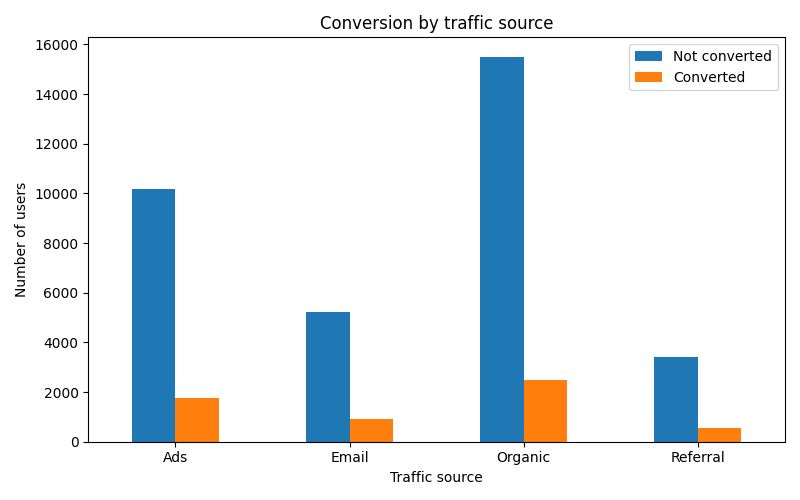

In [29]:
# Number of converted and non-converted users by traffic source
tabla_traffic.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Conversion by traffic source')
plt.xlabel('Traffic source')
plt.ylabel('Number of users')
plt.xticks(rotation=0)
plt.legend(['Not converted', 'Converted'])
plt.show()


- In absolute terms, **Organic accounts for the largest number of users**, so it also records the highest number of conversions. Referral has the lowest volume and, consequently, the lowest absolute number of conversions.


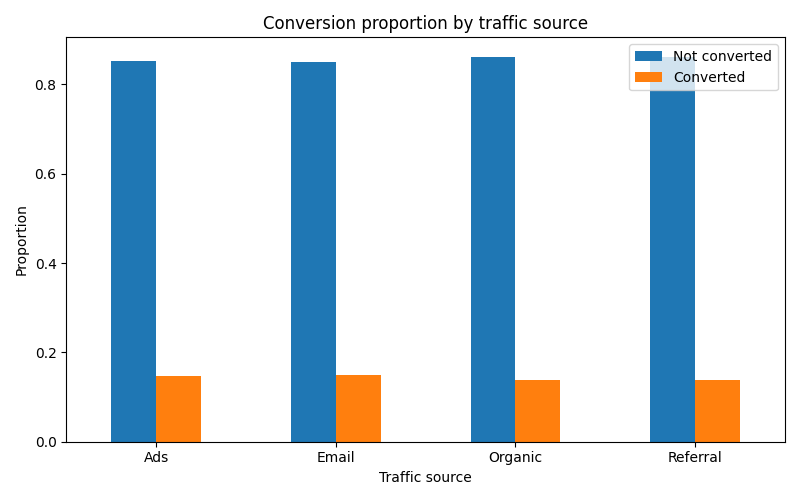

In [30]:
# Conversion proportion by traffic source
tabla_traffic_prop = pd.crosstab(
    df['traffic_source'],
    df['converted'],
    normalize='index'
)

tabla_traffic_prop.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Conversion proportion by traffic source')
plt.xlabel('Traffic source')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['Not converted', 'Converted'])
plt.show()


- When comparing proportions, conversion rates are quite similar across traffic sources. **Email has a slightly higher conversion proportion**, although the differences between channels are small.


### Relationship Between User Type and Conversion


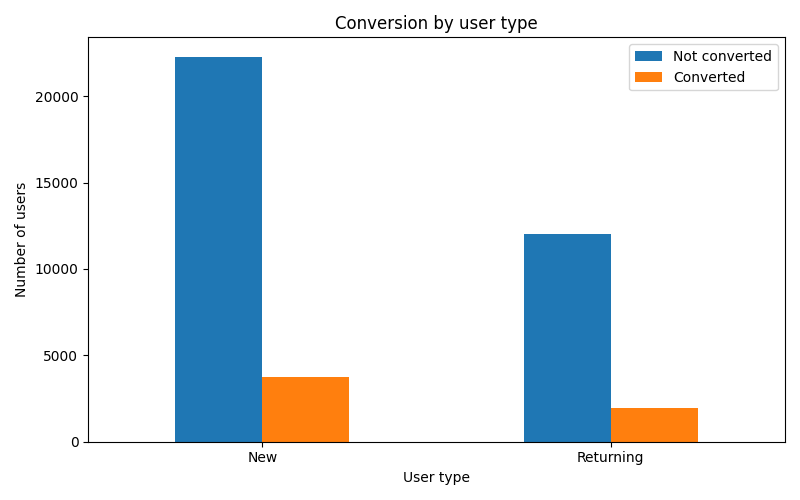

In [31]:
# Number of converted and non-converted users by user type
tabla_usuario_plot = tabla_usuario.rename(index={'Nuevo': 'New', 'Recurrente': 'Returning'})

tabla_usuario_plot.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Conversion by user type')
plt.xlabel('User type')
plt.ylabel('Number of users')
plt.xticks(rotation=0)
plt.legend(['Not converted', 'Converted'])
plt.show()


- New users account for a higher absolute number of both conversions and non-conversions, mainly because they represent a larger share of the sample. This higher volume does not by itself imply greater conversion effectiveness.


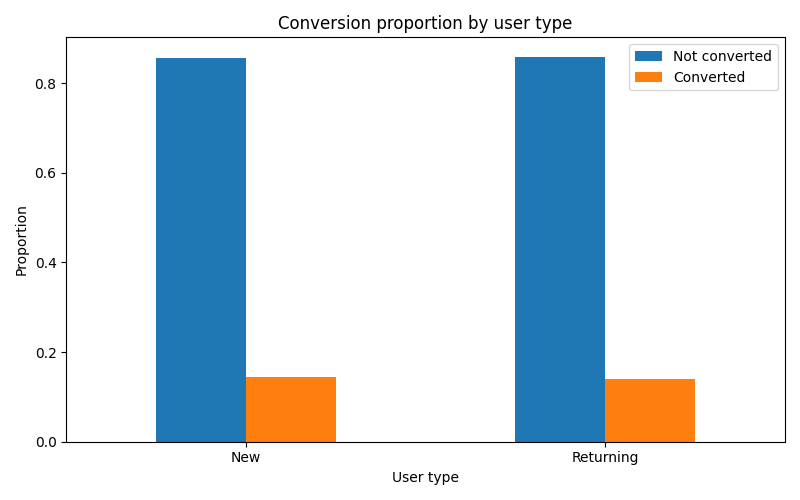

In [32]:
# Conversion proportion by user type
tabla_usuario_prop = pd.crosstab(
    df['user_type'],
    df['converted'],
    normalize='index'
)

tabla_usuario_prop_plot = tabla_usuario_prop.rename(index={'Nuevo': 'New', 'Recurrente': 'Returning'})

tabla_usuario_prop_plot.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Conversion proportion by user type')
plt.xlabel('User type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['Not converted', 'Converted'])
plt.show()


- Conversion rates are practically the same for new and returning users.
- Although new users have a slightly higher proportion, the difference is minimal, which is consistent with the chi-square test finding no statistically significant association between user type and conversion.


# 🧩 Step 7. Executive Insights for Stakeholders

The findings from the A/B experiment are translated into actionable business conclusions focused on **page version, conversion, average spending, traffic channels, and user type**.

## 7.1. Executive Answers

- **Which page generates higher conversion and average spending?**  
  **Page B** performs better on both metrics: an approximate conversion rate of **15.96% versus 12.57% for A**, and average spending among converted users of **68.75 versus 61.09**.

- **Which traffic channels are most effective at generating conversions?**  
  **Email** has the highest conversion rate (**14.99%**), followed by Ads (**14.74%**), Referral (**13.88%**), and Organic (**13.79%**). However, the differences are small and the association between traffic source and conversion is very weak.

- **Are there significant differences by user type?**  
  No. New users convert at approximately **14.36%** and returning users at **14.09%**, with no evidence of a statistically significant difference.

- **What recommendations can be made to optimize the marketing strategy?**  
  Prioritize **page B** as the candidate for implementation. For traffic channels, resources should not be reallocated solely on the basis of the observed conversion rates because the differences are small. The results should also be analyzed separately by page A/B to verify whether the aggregate patterns remain consistent.

---

## 7.2. 🌟 Key Findings from the A/B Experiment

### 7.2.1. 🔍 Page A vs B Comparison

**Average spending per user who converted:**

- The average spending of converted users was approximately **61.09 on page A** and **68.75 on page B**.
- Page B has average spending approximately **7.66 units higher**, equivalent to about **12.5% more than page A**.
- **Interpretation:** The difference is statistically significant. Among users who converted, page B is associated with higher average spending.

**Conversion rate:**

- Page A has an approximate conversion rate of **12.57%**, while page B reaches **15.96%**.
- Page B exceeds page A by approximately **3.38 percentage points**.
- **Interpretation:** The difference is statistically significant, so page B shows better conversion performance within the experiment.

---

### 7.2.2. 📊 Segmentation by Traffic Source

- Email has the highest conversion rate (**14.99%**), followed by Ads (**14.74%**), Referral (**13.88%**), and Organic (**13.79%**).
- **Interpretation:** The chi-square test found a statistically significant association between traffic source and conversion. However, Cramér's V (≈ **0.015**) indicates that the association is very weak, so differences between channels are small and should be interpreted with caution.

---

### 7.2.3. 📊 Segmentation by User Type

- New users have an approximate conversion rate of **14.36%**, compared with **14.09%** for returning users.
- Although new users account for a higher absolute number of conversions, this is mainly explained by their greater presence in the sample.
- **Interpretation:** No statistically significant differences were found between new and returning users, so user type does not appear to be a relevant factor for explaining conversion in this experiment.

---

## 7.3. 💡 Business Recommendations

- **Prioritize page B as the candidate version for implementation**, because it has a significantly higher conversion rate and higher average spending among converted users.

- **Do not modify the acquisition strategy solely on the basis of conversion rates by traffic source.** Although Email has the best result and Referral and Organic have slightly lower rates, the association found is very weak. Before reallocating resources, it is advisable to consider costs, volume, and profitability for each channel.

- **Do not prioritize differentiated strategies between new and returning users solely to increase conversion**, because no statistically significant differences were found between the two groups.

- **As a next step, segment the traffic-source and user-type analyses by pages A and B.** This will make it possible to verify whether the results observed at the aggregate level remain consistent within each page version and reduce the risk of a possible **Simpson's paradox**.

- **Complement the implementation decision with profitability metrics** to verify that the improvements observed on page B also represent a sufficient economic benefit for the business.
